# Statistics from scratch: standard errors, t-statistics, autocorrelation, regression CIs

This notebook builds the statistics you need for "is this result real?" questions, in
order, with the maths written out and every number computed by hand before a library
function is called.

The running question is the trader's one: **"the mean of my series is positive — do I
believe it?"** Answering it properly needs, in this order:

| Part | Idea | The formula you will be able to write down |
|---|---|---|
| A | mean, variance, standard deviation | $\bar x,\; s^2 = \frac{1}{n-1}\sum (x_i-\bar x)^2$ |
| B | the sampling distribution and the **standard error** | $\text{SE}(\bar x) = \sigma/\sqrt{n}$ |
| C | the **t-statistic**, p-value and confidence interval for a mean | $t = \bar x / (s/\sqrt n)$ |
| D | **autocorrelation** and why it makes the standard error wrong | $\text{SE}_{\text{true}} \approx \frac{s}{\sqrt n}\sqrt{\frac{1+\rho}{1-\rho}}$ |
| E | **linear regression**: the coefficient, its standard error and CI | $\hat b = \frac{S_{xy}}{S_{xx}},\; \text{SE}(\hat b)=\frac{\hat\sigma}{\sqrt{S_{xx}}}$ |
| F | putting it together on a real "signal" | |

Conventions: $n$ observations $x_1,\dots,x_n$; Greek letters ($\mu, \sigma, \rho, \beta$)
are the unknown truth, hats and Latin letters ($\bar x, s, \hat b$) are what we compute
from data. Synthetic data always uses `rng = np.random.default_rng(42)` so the numbers
are reproducible.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
%matplotlib inline

pd.set_option("display.width", 120)
np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(42)

## Part A — one sample: mean, variance, standard deviation

Start with five hourly "returns" (in EUR/MWh) so every number can be checked by eye.

In [2]:
x = np.array([2.0, -1.0, 4.0, 1.0, -1.0])
n = len(x)
print("n =", n)

n = 5


### A.1 The mean

$$\bar x = \frac{1}{n}\sum_{i=1}^{n} x_i$$

In [3]:
xbar = x.sum() / n
print("sum  :", x.sum())
print("mean :", xbar)
print("np.mean gives the same:", np.mean(x))

sum  : 5.0
mean : 1.0
np.mean gives the same: 1.0


### A.2 Deviations and the variance

The variance measures how far the values sit from their mean, on average, in squared
units:

$$s^2 = \frac{1}{n-1}\sum_{i=1}^{n}(x_i-\bar x)^2$$

Step by step: deviations, squared deviations, their sum, divided by $n-1$.

In [4]:
dev = x - xbar
sq = dev ** 2
print("deviations        :", dev)
print("squared deviations:", sq)
print("sum of squares    :", sq.sum())
s2 = sq.sum() / (n - 1)
print("variance s^2      :", s2)
s = np.sqrt(s2)
print("std s             :", round(s, 4))

deviations        : [ 1. -2.  3.  0. -2.]
squared deviations: [1. 4. 9. 0. 4.]
sum of squares    : 18.0
variance s^2      : 4.5
std s             : 2.1213


### A.3 Why divide by $n-1$ and not $n$? (`ddof`)

$\bar x$ was computed from the same data, so the deviations from $\bar x$ are a little
smaller than the deviations from the true $\mu$ (the sample mean is the point that
*minimises* the sum of squares). Dividing by $n$ therefore under-estimates $\sigma^2$;
dividing by $n-1$ corrects it exactly. `ddof` = "delta degrees of freedom" = what is
subtracted from $n$.

- `np.var(x)` and `np.std(x)` use `ddof=0` (divide by $n$) by default
- `pd.Series.var()` / `.std()` and `scipy.stats` use `ddof=1` (divide by $n-1$)

The simulation: draw many samples of size 5 from a population with $\sigma^2 = 4$ and
average the two estimators.

In [5]:
print("np.var(x)          (ddof=0):", np.var(x))
print("np.var(x, ddof=1)          :", np.var(x, ddof=1))
print("pd.Series(x).var() (ddof=1):", pd.Series(x).var())

np.var(x)          (ddof=0): 3.6
np.var(x, ddof=1)          : 4.5
pd.Series(x).var() (ddof=1): 4.5


In [6]:
samples = rng.normal(loc=0, scale=2, size=(20_000, 5))     # 20,000 samples of n=5, true variance 4
var_n   = samples.var(axis=1, ddof=0).mean()
var_nm1 = samples.var(axis=1, ddof=1).mean()
print("average of  sum/(n)   estimates:", round(var_n, 3), " (biased low; expected 4 * 4/5 = 3.2)")
print("average of  sum/(n-1) estimates:", round(var_nm1, 3), " (unbiased; expected 4)")

average of  sum/(n)   estimates: 3.221  (biased low; expected 4 * 4/5 = 3.2)
average of  sum/(n-1) estimates: 4.026  (unbiased; expected 4)


## Part B — the sampling distribution and the standard error

### B.1 The question

$\bar x = 1.0$ in our sample. If we had observed five *other* hours, $\bar x$ would
have been different. **How much does $\bar x$ move from sample to sample?** That spread
is the *standard error* of the mean. It is a standard deviation, but of the *estimate*,
not of the data.

### B.2 The formula and where it comes from

If the $x_i$ are independent with variance $\sigma^2$:

$$\operatorname{Var}(\bar x) = \operatorname{Var}\!\left(\frac{1}{n}\sum x_i\right)
= \frac{1}{n^2}\sum \operatorname{Var}(x_i) = \frac{1}{n^2}\, n\,\sigma^2 = \frac{\sigma^2}{n}$$

so

$$\text{SE}(\bar x) = \sqrt{\operatorname{Var}(\bar x)} = \frac{\sigma}{\sqrt n}
\qquad\text{estimated by}\qquad \widehat{\text{SE}} = \frac{s}{\sqrt n}$$

The step $\operatorname{Var}(\sum x_i) = \sum \operatorname{Var}(x_i)$ is only true when
the $x_i$ are **independent** (no covariance terms). Part D is about what happens when
they are not.

In [7]:
se_hat = s / np.sqrt(n)
print("s        :", round(s, 4))
print("sqrt(n)  :", round(np.sqrt(n), 4))
print("SE(xbar) :", round(se_hat, 4))
print("scipy.stats.sem(x) gives the same (it uses ddof=1):", round(stats.sem(x), 4))

s        : 2.1213
sqrt(n)  : 2.2361
SE(xbar) : 0.9487
scipy.stats.sem(x) gives the same (it uses ddof=1): 0.9487


### B.3 See it: simulate the sampling distribution

Population: hourly returns with true mean $\mu = 1$ and true sd $\sigma = 2$. Draw
10,000 samples of $n = 5$, compute the mean of each, and look at the spread of those
means. The formula says it should be $2/\sqrt5 = 0.894$.

In [8]:
mu, sigma = 1.0, 2.0
means_n5 = rng.normal(mu, sigma, size=(10_000, 5)).mean(axis=1)
print("first 5 sample means:", means_n5[:5])
print("mean of the means   :", round(means_n5.mean(), 4), " (≈ mu = 1)")
print("sd of the means     :", round(means_n5.std(ddof=1), 4), " (≈ sigma/sqrt(5) =", round(sigma / np.sqrt(5), 4), ")")

first 5 sample means: [2.3541 0.1659 0.6484 0.5663 0.8396]
mean of the means   : 0.9969  (≈ mu = 1)
sd of the means     : 0.8872  (≈ sigma/sqrt(5) = 0.8944 )


The same for several $n$: the data's spread ($\sigma = 2$) never changes; the spread of
the *mean* shrinks like $1/\sqrt n$. That is the whole difference between a standard
deviation and a standard error.

In [9]:
rows = []
for n_ in [5, 20, 100, 1000]:
    m = rng.normal(mu, sigma, size=(10_000, n_)).mean(axis=1)
    rows.append({"n": n_, "sd of data": sigma, "sd of sample means (simulated)": m.std(ddof=1), "sigma/sqrt(n)": sigma / np.sqrt(n_)})
pd.DataFrame(rows).round(4)

,n,sd of data,sd of sample means (simulated),sigma/sqrt(n)
0,5,2.0,0.8961,0.8944
1,20,2.0,0.4440,0.4472
2,100,2.0,0.1970,0.2000
3,1000,2.0,0.0633,0.0632


### B.4 The central limit theorem: the mean is normal even when the data is not

Skewed data (lognormal). The histogram of the data is lopsided; the histogram of sample
means for $n = 50$ is a bell. That is why $t$-tests and normal confidence intervals work
for means of non-normal data once $n$ is moderate.

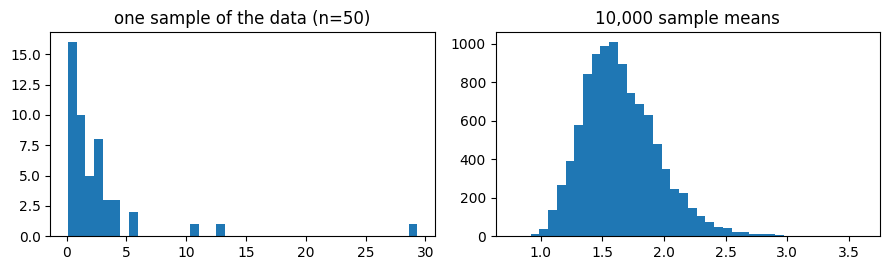

In [10]:
skewed = rng.lognormal(mean=0, sigma=1, size=(10_000, 50))
fig, ax = plt.subplots(1, 2, figsize=(9, 2.8))
ax[0].hist(skewed[0], bins=40); ax[0].set_title("one sample of the data (n=50)")
ax[1].hist(skewed.mean(axis=1), bins=40); ax[1].set_title("10,000 sample means")
plt.tight_layout()

**Interview check:** "What is the standard error of a mean of 100 hourly returns with
sd 3?" $3/\sqrt{100} = 0.3$. "And of the *sum*?" $3\sqrt{100} = 30$.

## Part C — the t-statistic: "is the mean positive?"

### C.1 The idea

We have $\bar x = 1.0$ with $\widehat{\text{SE}} = 0.949$. Is the true mean $\mu$
positive, or could a mean of 1.0 easily happen by chance when $\mu = 0$?

Set up the boring explanation as the **null hypothesis** $H_0: \mu = 0$ and measure how
many standard errors away from 0 our estimate is:

$$t = \frac{\bar x - 0}{\,s/\sqrt n\,}$$

If $H_0$ is true and the data are independent and roughly normal, $t$ follows a
**Student t distribution with $n-1$ degrees of freedom** (a normal with fatter tails,
because $s$ is itself noisy for small $n$). For large $n$ it is just a normal.

In [11]:
t_stat = (xbar - 0) / (s / np.sqrt(n))
print("xbar   :", xbar)
print("SE     :", round(s / np.sqrt(n), 4))
print("t      :", round(t_stat, 4))

xbar   : 1.0
SE     : 0.9487
t      : 1.0541


### C.2 The p-value

The p-value is the probability, *if $H_0$ were true*, of a $t$ at least as extreme as
the one observed.

- two-sided ("is $\mu \ne 0$?"): $p = 2\,P(T_{n-1} > |t|)$
- one-sided ("is $\mu > 0$?"): $p = P(T_{n-1} > t)$

`stats.t.sf(t, df)` is the *survival function* $P(T > t) = 1 - \text{cdf}(t)$.

In [12]:
df_ = n - 1
p_two = 2 * stats.t.sf(abs(t_stat), df=df_)
p_one = stats.t.sf(t_stat, df=df_)
print("df           :", df_)
print("two-sided p  :", round(p_two, 4))
print("one-sided p  :", round(p_one, 4))

df           : 4
two-sided p  : 0.3513
one-sided p  : 0.1757


In [13]:
res = stats.ttest_1samp(x, popmean=0)                     # two-sided by default
print("scipy t      :", round(res.statistic, 4))
print("scipy p      :", round(res.pvalue, 4))
res1 = stats.ttest_1samp(x, popmean=0, alternative="greater")
print("one-sided p  :", round(res1.pvalue, 4))

scipy t      : 1.0541
scipy p      : 0.3513
one-sided p  : 0.1757


With five observations a mean of 1.0 is only about one standard error from zero:
$p \approx 0.36$. The data are consistent with $\mu = 0$. That is not "the mean is
zero"; it is "five points cannot tell".

### C.3 See it: what $t$ looks like when $H_0$ is true

Simulate 20,000 samples of $n = 5$ from a population with $\mu = 0$, compute $t$ each
time, and compare with the $t_4$ density. Then count how often $|t|$ exceeds the 5%
critical value: it should be about 5%. **That is what "significant at 5%" means: a
threshold that a null world crosses one time in twenty.**

In [14]:
null_samples = rng.normal(0, 2, size=(20_000, 5))
t_null = null_samples.mean(axis=1) / (null_samples.std(axis=1, ddof=1) / np.sqrt(5))
t_crit = stats.t.ppf(0.975, df=4)                         # ppf = inverse cdf: the 97.5% point
print("critical |t| for 5% two-sided, df=4:", round(t_crit, 4))
print("fraction of null samples with |t| > critical:", round((np.abs(t_null) > t_crit).mean(), 4))
print("fraction with |t| > 1.96 (normal critical):  ", round((np.abs(t_null) > 1.96).mean(), 4), " <- too many: fat tails at n=5")

critical |t| for 5% two-sided, df=4: 2.7764
fraction of null samples with |t| > critical: 0.0472
fraction with |t| > 1.96 (normal critical):   0.1186  <- too many: fat tails at n=5


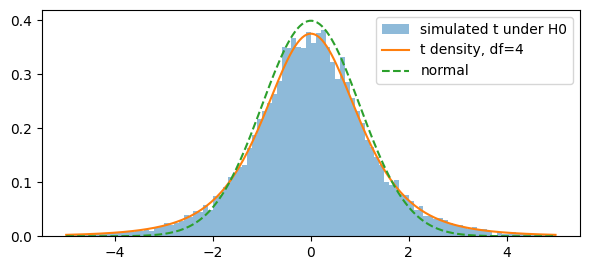

In [15]:
grid = np.linspace(-5, 5, 200)
plt.figure(figsize=(6, 2.8))
plt.hist(t_null, bins=100, range=(-5, 5), density=True, alpha=.5, label="simulated t under H0")
plt.plot(grid, stats.t.pdf(grid, df=4), label="t density, df=4")
plt.plot(grid, stats.norm.pdf(grid), "--", label="normal")
plt.legend(); plt.tight_layout()

### C.4 The confidence interval for the mean

Flip the test around: which values of $\mu$ would *not* be rejected? That set is the
confidence interval:

$$\bar x \;\pm\; t_{n-1,\,0.975}\cdot\frac{s}{\sqrt n}$$

"95%" describes the procedure: if you repeated the experiment many times, 95% of the
intervals built this way would contain the true $\mu$. Check by simulation.

In [16]:
ci_low  = xbar - t_crit * s / np.sqrt(n)
ci_high = xbar + t_crit * s / np.sqrt(n)
print("95% CI for mu:", (round(ci_low, 3), round(ci_high, 3)), " <- contains 0, consistent with p = 0.36")

95% CI for mu: (-1.634, 3.634)  <- contains 0, consistent with p = 0.36


In [17]:
sims = rng.normal(mu, sigma, size=(10_000, 5))            # true mu = 1
m = sims.mean(axis=1); sd = sims.std(axis=1, ddof=1)
low, high = m - t_crit * sd / np.sqrt(5), m + t_crit * sd / np.sqrt(5)
covered = (low <= mu) & (mu <= high)
print("fraction of intervals containing the true mean:", round(covered.mean(), 4))
print("first 5 intervals:", [(round(a, 2), round(b, 2)) for a, b in zip(low[:5], high[:5])])

fraction of intervals containing the true mean: 0.9547
first 5 intervals: [(-2.07, 2.63), (-0.2, 2.0), (-1.34, 2.73), (-0.52, 2.69), (-2.46, 4.53)]


### C.5 Sample size, effect size, and the difference between "significant" and "big"

The $t$-statistic is the effect in standard-error units. Hold the effect and the noise
fixed ($\bar x = 0.2$, $s = 2$) and change $n$:

In [18]:
rows = []
for n_ in [10, 100, 1000, 10_000, 100_000]:
    t_ = 0.2 / (2 / np.sqrt(n_))
    rows.append({"n": n_, "mean": 0.2, "sd": 2, "SE": 2 / np.sqrt(n_), "t": t_, "two-sided p": 2 * stats.t.sf(t_, df=n_ - 1)})
pd.DataFrame(rows).round(4)

,n,mean,sd,SE,t,two-sided p
0,10,0.2,2,0.6325,0.3162,0.7590
1,100,0.2,2,0.2000,1.0000,0.3197
2,1000,0.2,2,0.0632,3.1623,0.0016
3,10000,0.2,2,0.0200,10.0000,0.0000
4,100000,0.2,2,0.0063,31.6228,0.0000


The same 0.2 EUR/MWh edge is "not significant" at $n = 100$ and "overwhelmingly
significant" at $n = 100{,}000$. The size of the edge did not change. Always report the
estimate with its CI, not only the p-value.

### C.6 Real data: are hourly price changes positive on average?

Hourly day-ahead price changes from the power file. This is the naive calculation;
Part D shows why it is wrong for this series.

In [19]:
df = pd.read_csv("../data/hourly_power_clean.csv", parse_dates=["time"]).set_index("time")
dp = df["price_eur_mwh"].diff().dropna()                  # hourly change in price
n_real = len(dp)
xbar_r, s_r = dp.mean(), dp.std()                          # pandas std: ddof=1
se_r = s_r / np.sqrt(n_real)
t_r = xbar_r / se_r
print("n      :", n_real)
print("mean   :", round(xbar_r, 4), "EUR/MWh per hour")
print("sd     :", round(s_r, 4))
print("SE     :", round(se_r, 4))
print("t      :", round(t_r, 4), "  two-sided p:", round(2 * stats.t.sf(abs(t_r), df=n_real - 1), 4))

n      : 17519
mean   : -0.0014 EUR/MWh per hour
sd     : 24.1862
SE     : 0.1827
t      : -0.0078   two-sided p: 0.9938


A synthetic "strategy" series for contrast: 500 daily P&Ls with a real positive drift
(mean 0.1, sd 1). The sample mean lands near 0.1 and the $t$ is above 2, so here the
data *can* tell.

In [20]:
rng_pnl = np.random.default_rng(21)
pnl = rng_pnl.normal(0.1, 1.0, size=500)                   # true mean 0.1, sd 1 -> Sharpe 0.1 per day
t_pnl = pnl.mean() / (pnl.std(ddof=1) / np.sqrt(len(pnl)))
print("mean :", round(pnl.mean(), 4), " SE :", round(pnl.std(ddof=1) / np.sqrt(500), 4), " t :", round(t_pnl, 3))
print("one-sided p (mean > 0):", round(stats.t.sf(t_pnl, df=499), 4))
print("Note: t = Sharpe * sqrt(n). True Sharpe 0.1/day over 500 days -> expected t ≈", round(0.1 * np.sqrt(500), 2))

mean : 0.1033  SE : 0.0418  t : 2.472
one-sided p (mean > 0): 0.0069
Note: t = Sharpe * sqrt(n). True Sharpe 0.1/day over 500 days -> expected t ≈ 2.24


**Interview check:** "A strategy has an annualised Sharpe of 1.0 over 3 years. Is it
significant?" $t = \text{SR}\sqrt{T} = 1.0\sqrt3 = 1.73$: not at the 5% level. You need
about 4 years of Sharpe 1 for $t = 2$.

## Part D — autocorrelation, and why it breaks the standard error

### D.1 What autocorrelation is

The correlation between a series and itself shifted by $k$ steps:

$$\rho_k = \frac{\sum_{t=k+1}^{n}(x_t-\bar x)(x_{t-k}-\bar x)}{\sum_{t=1}^{n}(x_t-\bar x)^2}$$

Numerator: products of *neighbouring* deviations. Denominator: the total sum of squares
(so $\rho_0 = 1$). By hand on six values, lag 1:

In [21]:
z = pd.Series([2.0, 3.0, 5.0, 4.0, 6.0, 4.0])
zc = z - z.mean()
pairs = pd.DataFrame({"x_t": z, "x_t-1": z.shift(1), "dev_t": zc, "dev_t-1": zc.shift(1), "product": zc * zc.shift(1)})
pairs

,x_t,x_t-1,dev_t,dev_t-1,product
0,2.0,NaN,-2.0,NaN,NaN
1,3.0,2.0,-1.0,-2.0,2.0
2,5.0,3.0,1.0,-1.0,-1.0
3,4.0,5.0,0.0,1.0,0.0
4,6.0,4.0,2.0,0.0,0.0
5,4.0,6.0,0.0,2.0,0.0


In [22]:
num = (zc * zc.shift(1)).sum()                            # NaN in row 0 is skipped
den = (zc ** 2).sum()
print("numerator   :", round(num, 4))
print("denominator :", round(den, 4))
print("rho_1       :", round(num / den, 4))

numerator   : 1.0
denominator : 10.0
rho_1       : 0.1


`pd.Series.autocorr(lag=1)` computes the plain Pearson correlation between the aligned
pairs $(x_t, x_{t-1})$ instead, each side with its own mean. On short series the two
differ slightly; on long series they agree. The formula above is the one used in ACF
plots and in the corrections below.

In [23]:
print("pd .autocorr(1):", round(z.autocorr(1), 4))
print("np.corrcoef    :", round(np.corrcoef(z[1:], z[:-1])[0, 1], 4))

pd .autocorr(1): 0.1387
np.corrcoef    : 0.1387


### D.2 A series with known autocorrelation: AR(1)

$$x_t = \phi\, x_{t-1} + \varepsilon_t,\qquad \varepsilon_t \sim N(0, 1)$$

Its autocorrelation at lag $k$ is exactly $\phi^k$. Simulate with $\phi = 0.8$ and
check: $\rho_1 = 0.8,\ \rho_2 = 0.64,\ \rho_3 = 0.512$.

In [24]:
def ar1(phi, n, rng):
    eps = rng.normal(0, 1, n)
    out = np.zeros(n)
    for t in range(1, n):
        out[t] = phi * out[t - 1] + eps[t]
    return out

def acf(x, k):
    xc = x - x.mean()
    return (xc[k:] * xc[:-k]).sum() / (xc ** 2).sum()

phi = 0.8
ar = ar1(phi, 5000, rng)
print("first values:", ar[:5])
for k in [1, 2, 3, 10]:
    print(f"lag {k:2d}: estimated rho = {acf(ar, k):.3f}   theory phi^k = {phi**k:.3f}")

first values: [ 0.      0.7678  0.1913 -0.7832  0.2927]
lag  1: estimated rho = 0.800   theory phi^k = 0.800
lag  2: estimated rho = 0.641   theory phi^k = 0.640
lag  3: estimated rho = 0.511   theory phi^k = 0.512
lag 10: estimated rho = 0.115   theory phi^k = 0.107


### D.3 Why it breaks the standard error

Go back to the derivation in B.2. With correlation, $\operatorname{Var}(\sum x_i)$ has
covariance terms:

$$\operatorname{Var}\!\left(\sum_{t=1}^n x_t\right) = n\sigma^2 + 2\sum_{k=1}^{n-1}(n-k)\,\gamma_k,
\qquad \gamma_k = \sigma^2\rho_k$$

For large $n$ this gives

$$\operatorname{Var}(\bar x) \approx \frac{\sigma^2}{n}\Bigl(1 + 2\sum_{k\ge1}\rho_k\Bigr)
\;\overset{\text{AR(1)}}{=}\; \frac{\sigma^2}{n}\cdot\frac{1+\phi}{1-\phi}$$

(using $\sum_{k\ge1}\phi^k = \phi/(1-\phi)$). With $\phi = 0.8$ the factor is
$1.8/0.2 = 9$: the true variance of the mean is **nine times** what the iid formula
says, so the true SE is **three times** larger and the naive $t$ is three times too big.

Equivalent statement: $n$ correlated points carry the information of

$$n_{\text{eff}} = n\,\frac{1-\phi}{1+\phi}$$

independent ones. 5,000 points with $\phi = 0.8$ are worth about 556.

Simulation: draw many AR(1) series of length 200, look at the spread of their means, and
compare with the naive and corrected formulas.

In [25]:
n_ = 200
means_ar = np.array([ar1(phi, n_, rng).mean() for _ in range(3000)])
sd_data = np.std(ar1(phi, 50_000, rng), ddof=1)           # sigma of the AR(1) process itself
naive_se = sd_data / np.sqrt(n_)
corrected_se = naive_se * np.sqrt((1 + phi) / (1 - phi))
print("true sd of sample means (simulated):", round(means_ar.std(ddof=1), 4))
print("naive     sigma/sqrt(n)            :", round(naive_se, 4))
print("corrected sigma/sqrt(n)*sqrt((1+phi)/(1-phi)):", round(corrected_se, 4))
print("n_eff = n(1-phi)/(1+phi)           :", round(n_ * (1 - phi) / (1 + phi), 1), "of", n_)

true sd of sample means (simulated):

 0.3467
naive     sigma/sqrt(n)            : 0.1177
corrected sigma/sqrt(n)*sqrt((1+phi)/(1-phi)): 0.353
n_eff = n(1-phi)/(1+phi)           : 22.2 of 200


### D.4 The consequence for the t-test: false positives

Test $H_0: \mu = 0$ on AR(1) series whose true mean *is* zero. The naive $t$ rejects
about half the time instead of 5%. Dividing by $\sqrt{(1+\hat\rho_1)/(1-\hat\rho_1)}$
brings it back close to 5% (a little above, because $\rho_1$ is estimated from only 200
points and the AR(1) factor is an approximation).

In [26]:
rej_naive = rej_corr = 0
trials = 2000
for _ in range(trials):
    y = ar1(phi, 200, rng)
    t_naive = y.mean() / (y.std(ddof=1) / np.sqrt(200))
    rho1 = acf(y, 1)
    t_corr = t_naive / np.sqrt((1 + rho1) / (1 - rho1))
    rej_naive += abs(t_naive) > 1.96
    rej_corr += abs(t_corr) > 1.96
print("false-positive rate, naive t    :", round(rej_naive / trials, 3), " (should be 0.05)")
print("false-positive rate, corrected t:", round(rej_corr / trials, 3))

false-positive rate, naive t    : 0.542  (should be 0.05)
false-positive rate, corrected t: 0.086


### D.5 A more general correction: Newey–West (HAC) standard error

The AR(1) factor assumes a specific pattern. The Newey–West estimator uses the first
$L$ sample autocovariances with declining (Bartlett) weights and works for any
short-memory dependence:

$$\widehat{\operatorname{Var}}_{NW}(\bar x) = \frac{1}{n}\Bigl(\hat\gamma_0 + 2\sum_{k=1}^{L}\bigl(1-\tfrac{k}{L+1}\bigr)\hat\gamma_k\Bigr),
\qquad \hat\gamma_k = \frac{1}{n}\sum_{t=k+1}^{n}(x_t-\bar x)(x_{t-k}-\bar x)$$

A common rule for $L$ is $\lfloor 4 (n/100)^{2/9} \rfloor$; for hourly data with daily
seasonality use at least 24.

In [27]:
def nw_se_mean(x, L):
    x = np.asarray(x, dtype=float)
    n = len(x)
    xc = x - x.mean()
    gamma = [(xc[k:] * xc[:-k]).sum() / n if k > 0 else (xc ** 2).sum() / n for k in range(L + 1)]
    weights = [1 - k / (L + 1) for k in range(L + 1)]
    var_sum = gamma[0] + 2 * sum(w * g for w, g in zip(weights[1:], gamma[1:]))
    return np.sqrt(var_sum / n)

y = ar1(phi, 2000, rng)
print("naive SE           :", round(y.std(ddof=1) / np.sqrt(2000), 4))
print("AR(1)-factor SE    :", round(y.std(ddof=1) / np.sqrt(2000) * np.sqrt((1 + acf(y, 1)) / (1 - acf(y, 1))), 4))
print("Newey-West SE, L=20:", round(nw_se_mean(y, 20), 4))

naive SE           : 0.0355
AR(1)-factor SE    : 0.1002
Newey-West SE, L=20: 0.0904


### D.6 Real data, done properly

Back to the hourly price changes of C.6. First look at the autocorrelation, then redo
the $t$-statistic three ways.

In [28]:
dpv = dp.to_numpy()
print("lag-1 autocorrelation of hourly price changes :", round(acf(dpv, 1), 3))
print("lag-24 autocorrelation                         :", round(acf(dpv, 24), 3))

lag-1 autocorrelation of hourly price changes : -0.291
lag-24 autocorrelation                         : 0.159


In [29]:
rho1 = acf(dpv, 1)
se_naive = dpv.std(ddof=1) / np.sqrt(n_real)
se_ar1 = se_naive * np.sqrt((1 + rho1) / (1 - rho1))
se_nw = nw_se_mean(dpv, 48)
pd.DataFrame({
    "SE": [se_naive, se_ar1, se_nw],
    "t": [xbar_r / se_naive, xbar_r / se_ar1, xbar_r / se_nw],
}, index=["naive iid", "AR(1) factor", "Newey-West L=48"]).round(4)

,SE,t
naive iid,0.1827,-0.0078
AR(1) factor,0.1354,-0.0105
Newey-West L=48,0.0350,-0.0408


Price *changes* are negatively autocorrelated (a rise tends to be followed by a fall),
so the corrected SE is *smaller* than the naive one, and Newey–West makes it much
smaller. That is not a fluke: the mean of the changes is $(p_n - p_1)/(n-1)$, a
telescoping sum, so its uncertainty is set by two prices, not by 17,519 noisy
increments. Differencing a stationary series drives its long-run variance towards zero,
and Newey–West sees that through the negative autocovariances.

The sign of $\rho_1$ decides the direction of the correction. Positive autocorrelation
(levels, slow-moving series, residuals of a model that misses a lag) is the common and
dangerous case: it makes the naive $t$ too *large*. Either way, here the mean change is
indistinguishable from zero.

Now a series with strong positive autocorrelation: consumption minus its hour-of-day
average. The naive $t$ for "is the residual mean different from zero in 2023?" is
enormous; the corrected one is not.

In [30]:
cons = df["consumption_mwh"]
resid = (cons - cons.groupby(cons.index.hour).transform("mean"))
r23 = resid.loc["2023"].to_numpy()
rho1 = acf(r23, 1)
se_naive = r23.std(ddof=1) / np.sqrt(len(r23))
print("n:", len(r23), " mean:", round(r23.mean(), 1), " lag-1 rho:", round(rho1, 3))
print("naive t     :", round(r23.mean() / se_naive, 2))
print("AR(1) t     :", round(r23.mean() / (se_naive * np.sqrt((1 + rho1) / (1 - rho1))), 2))
print("Newey-West t:", round(r23.mean() / nw_se_mean(r23, 168), 2))
print("n_eff       :", round(len(r23) * (1 - rho1) / (1 + rho1)))

n: 8760  mean: -92.1  lag-1 rho: 0.969
naive t     : -3.77
AR(1) t     : -0.48
Newey-West t: -0.36
n_eff       : 140


**Interview check:** "You have 17,520 hourly observations, the t-stat is 12 — is it
significant?" First question back: what is the lag-1 autocorrelation? With $\rho = 0.95$
the effective sample is $17{,}520 \times 0.05/1.95 \approx 450$ and the honest $t$ is
about $12/\sqrt{39} \approx 2$.

## Part E — linear regression: the coefficient, its standard error, its CI

### E.1 The model and the estimate

$$y_i = a + b\,x_i + \varepsilon_i,\qquad \varepsilon_i \sim (0, \sigma^2)\ \text{independent}$$

Ordinary least squares picks $a, b$ to minimise $\sum (y_i - a - b x_i)^2$. Setting the
derivatives to zero gives

$$\hat b = \frac{S_{xy}}{S_{xx}} = \frac{\sum (x_i-\bar x)(y_i-\bar y)}{\sum (x_i-\bar x)^2},
\qquad \hat a = \bar y - \hat b\,\bar x$$

Six points generated from $y = 3 + 2x + \text{noise}$, so the answer should be near
$b = 2$, $a = 3$.

In [31]:
xr = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0])
yr = np.array([5.1, 6.8, 9.2, 11.1, 12.8, 15.3])
tbl = pd.DataFrame({"x": xr, "y": yr, "x-xbar": xr - xr.mean(), "y-ybar": yr - yr.mean()})
tbl["(x-xbar)(y-ybar)"] = tbl["x-xbar"] * tbl["y-ybar"]
tbl["(x-xbar)^2"] = tbl["x-xbar"] ** 2
tbl

,x,y,x-xbar,y-ybar,(x-xbar)(y-ybar),(x-xbar)^2
0,1.0,5.1,-2.5,-4.95,12.375,6.25
1,2.0,6.8,-1.5,-3.25,4.875,2.25
2,3.0,9.2,-0.5,-0.85,0.425,0.25
3,4.0,11.1,0.5,1.05,0.525,0.25
4,5.0,12.8,1.5,2.75,4.125,2.25
5,6.0,15.3,2.5,5.25,13.125,6.25


In [32]:
Sxy = tbl["(x-xbar)(y-ybar)"].sum()
Sxx = tbl["(x-xbar)^2"].sum()
b_hat = Sxy / Sxx
a_hat = yr.mean() - b_hat * xr.mean()
print("Sxy :", round(Sxy, 4), " Sxx :", round(Sxx, 4))
print("b_hat = Sxy/Sxx        :", round(b_hat, 4))
print("a_hat = ybar - b*xbar  :", round(a_hat, 4))

Sxy : 35.45  Sxx : 17.5
b_hat = Sxy/Sxx        : 2.0257
a_hat = ybar - b*xbar  : 2.96


Three library calls that return the same numbers, and what each gives you:

- `np.polyfit(x, y, 1)`: `[slope, intercept]`, nothing else
- `scipy.stats.linregress(x, y)`: slope, intercept, r, p-value **and the slope's standard error**
- `sklearn LinearRegression`: `coef_`, `intercept_`; no standard errors at all (it is a prediction tool)

In [33]:
print("np.polyfit      :", np.polyfit(xr, yr, 1))
lr = stats.linregress(xr, yr)
print("linregress      : slope", round(lr.slope, 4), " intercept", round(lr.intercept, 4), " stderr", round(lr.stderr, 4))
from sklearn.linear_model import LinearRegression
m = LinearRegression().fit(xr.reshape(-1, 1), yr)
print("sklearn         : coef_", m.coef_, " intercept_", round(m.intercept_, 4))

np.polyfit      : [2.0257 2.96  ]
linregress      : slope 2.0257  intercept 2.96  stderr 0.0539


sklearn         : coef_ [2.0257]  intercept_ 2.96


### E.2 Residuals and the noise estimate

$$\hat y_i = \hat a + \hat b x_i,\qquad e_i = y_i - \hat y_i,\qquad
\hat\sigma^2 = \frac{\text{RSS}}{n-2} = \frac{\sum e_i^2}{n-2}$$

$n - 2$ because two parameters were estimated from the data (same logic as $n-1$ for
the variance).

In [34]:
y_hat = a_hat + b_hat * xr
e = yr - y_hat
pd.DataFrame({"x": xr, "y": yr, "y_hat": y_hat.round(4), "residual": e.round(4)})

,x,y,y_hat,residual
0,1.0,5.1,4.9857,0.1143
1,2.0,6.8,7.0114,-0.2114
2,3.0,9.2,9.0371,0.1629
3,4.0,11.1,11.0629,0.0371
4,5.0,12.8,13.0886,-0.2886
5,6.0,15.3,15.1143,0.1857


In [35]:
RSS = (e ** 2).sum()
sigma2_hat = RSS / (len(xr) - 2)
print("RSS        :", round(RSS, 4))
print("sigma^2_hat:", round(sigma2_hat, 4), "  sigma_hat:", round(np.sqrt(sigma2_hat), 4))

RSS        : 0.2034
sigma^2_hat: 0.0509   sigma_hat: 0.2255


### E.3 The standard error of the slope, and where it comes from

Substitute $y_i = a + b x_i + \varepsilon_i$ into $\hat b = \sum w_i y_i$ with
$w_i = (x_i - \bar x)/S_{xx}$: the $a$ and $b$ parts collapse to $b$ exactly, so

$$\hat b = b + \sum_i w_i\,\varepsilon_i
\;\Rightarrow\;
\operatorname{Var}(\hat b) = \sigma^2 \sum_i w_i^2 = \frac{\sigma^2}{S_{xx}}
\;\Rightarrow\;
\text{SE}(\hat b) = \frac{\hat\sigma}{\sqrt{S_{xx}}}$$

Three things make the slope precise: small noise $\sigma$, many points, and **spread in
$x$** (large $S_{xx}$). You cannot estimate the effect of temperature from a week where
temperature barely moved.

In [36]:
se_b = np.sqrt(sigma2_hat / Sxx)
print("SE(b) by hand       :", round(se_b, 4))
print("linregress.stderr   :", round(lr.stderr, 4))

SE(b) by hand       : 0.0539
linregress.stderr   : 0.0539


### E.4 t-statistic, p-value and confidence interval for the slope

Exactly as for a mean, with $n - 2$ degrees of freedom:

$$t = \frac{\hat b - 0}{\text{SE}(\hat b)},\qquad
\text{CI}_{95\%} = \hat b \pm t_{n-2,\,0.975}\,\text{SE}(\hat b)$$

In [37]:
df_b = len(xr) - 2
t_b = b_hat / se_b
crit = stats.t.ppf(0.975, df=df_b)
print("t for slope     :", round(t_b, 3), "  p:", round(2 * stats.t.sf(abs(t_b), df=df_b), 6))
print("95% CI for slope:", (round(b_hat - crit * se_b, 4), round(b_hat + crit * se_b, 4)), " <- contains the true 2.0")
print("linregress p    :", round(lr.pvalue, 6))

t for slope     : 37.577   p: 3e-06
95% CI for slope: (1.876, 2.1754)  <- contains the true 2.0
linregress p    : 3e-06


### E.5 See it: the slope's sampling distribution

Keep the same six $x$ values, regenerate the noise 5,000 times with $\sigma = 0.4$, refit.
The spread of the fitted slopes should equal $\sigma/\sqrt{S_{xx}} = 0.4/\sqrt{17.5}$,
and 95% of the CIs should contain 2.

In [38]:
true_a, true_b, true_sigma = 3.0, 2.0, 0.4
slopes, covered = [], []
for _ in range(5000):
    ysim = true_a + true_b * xr + rng.normal(0, true_sigma, size=6)
    r = stats.linregress(xr, ysim)
    slopes.append(r.slope)
    covered.append(r.slope - crit * r.stderr <= true_b <= r.slope + crit * r.stderr)
slopes = np.array(slopes)
print("sd of fitted slopes (simulated):", round(slopes.std(ddof=1), 4))
print("sigma/sqrt(Sxx)                :", round(true_sigma / np.sqrt(Sxx), 4))
print("CI coverage                    :", round(np.mean(covered), 3))

sd of fitted slopes (simulated): 0.0972
sigma/sqrt(Sxx)                : 0.0956
CI coverage                    : 0.95


### E.6 What drives SE(b): noise, n, and spread of x

Same true slope; change one ingredient at a time.

In [39]:
def se_slope(x, sigma):
    return sigma / np.sqrt(((x - x.mean()) ** 2).sum())

pd.DataFrame([
    {"case": "baseline: x=1..6, sigma=0.4",      "SE(b)": se_slope(np.arange(1, 7.0), 0.4)},
    {"case": "noise doubled: sigma=0.8",          "SE(b)": se_slope(np.arange(1, 7.0), 0.8)},
    {"case": "4x more points: x=1..24",           "SE(b)": se_slope(np.arange(1, 25.0), 0.4)},
    {"case": "x squeezed: x=1..6 step 0.2",       "SE(b)": se_slope(np.arange(1, 2.2, 0.2), 0.4)},
    {"case": "x spread: x=1..6 step 5",           "SE(b)": se_slope(np.arange(1, 31.0, 5), 0.4)},
]).round(4)

,case,SE(b)
0,"baseline: x=1..6, sigma=0.4",0.0956
1,noise doubled: sigma=0.8,0.1912
2,4x more points: x=1..24,0.0118
3,x squeezed: x=1..6 step 0.2,0.3780
4,x spread: x=1..6 step 5,0.0191


### E.7 Several regressors: the matrix form

With a column of ones and $p$ regressors in $X$ ($n \times (p+1)$):

$$\hat\beta = (X^\top X)^{-1}X^\top y,\qquad
\operatorname{Var}(\hat\beta) = \hat\sigma^2 (X^\top X)^{-1},\qquad
\hat\sigma^2 = \frac{\text{RSS}}{n-p-1}$$

The standard errors are the square roots of the diagonal. For one regressor this is the
same as E.3 ($X^\top X$ contains $S_{xx}$ after centring). Check on the six points, then
add a second regressor.

In [40]:
X = np.column_stack([np.ones(6), xr])
XtX_inv = np.linalg.inv(X.T @ X)
beta = XtX_inv @ X.T @ yr
res_m = yr - X @ beta
sigma2_m = (res_m ** 2).sum() / (6 - 2)
se_beta = np.sqrt(np.diag(sigma2_m * XtX_inv))
pd.DataFrame({"coef": beta, "SE": se_beta, "t": beta / se_beta}, index=["intercept", "x"]).round(4)

,coef,SE,t
intercept,2.9600,0.2099,14.0990
x,2.0257,0.0539,37.5769


In [41]:
x2 = np.array([0.0, 1.0, 0.0, 1.0, 0.0, 1.0])            # a second regressor (e.g. weekend flag)
X2 = np.column_stack([np.ones(6), xr, x2])
XtX2_inv = np.linalg.inv(X2.T @ X2)
beta2 = XtX2_inv @ X2.T @ yr
sigma2_2 = ((yr - X2 @ beta2) ** 2).sum() / (6 - 3)
se2 = np.sqrt(np.diag(sigma2_2 * XtX2_inv))
pd.DataFrame({"coef": beta2, "SE": se2, "t": beta2 / se2}, index=["intercept", "x", "x2"]).round(4)

,coef,SE,t
intercept,2.9583,0.2464,12.0058
x,2.0250,0.0651,31.1130
x2,0.0083,0.2223,0.0375


`np.linalg.lstsq(X, y)` and sklearn give the same $\hat\beta$; neither gives the SEs,
which is why this cell exists. (statsmodels would print this table; it is not in the
interview toolkit, so know how to do it by hand.)

### E.8 R²: how much of $y$ the line explains

$$R^2 = 1 - \frac{\text{RSS}}{\text{TSS}},\qquad \text{TSS} = \sum (y_i - \bar y)^2$$

In simple regression $R^2 = r_{xy}^2$. A high $R^2$ says the line fits *this* sample;
it says nothing about whether $\hat b$ would be the same in another sample: that is what
$\text{SE}(\hat b)$ is for.

In [42]:
TSS = ((yr - yr.mean()) ** 2).sum()
print("R^2 = 1 - RSS/TSS :", round(1 - RSS / TSS, 4))
print("r_xy^2            :", round(np.corrcoef(xr, yr)[0, 1] ** 2, 4))

R^2 = 1 - RSS/TSS : 0.9972
r_xy^2            : 0.9972


### E.9 Real data: consumption against heating degree

Hourly 2022 data: consumption with the hour-of-day average removed, regressed on the
heating degree $\max(15 - T, 0)$. The coefficient is "MWh per degree of cold", with its
naive SE, $t$ and CI. Then the residual autocorrelation, and the Newey–West correction of
the slope's SE.

For a regression the HAC variance is built from the *scores* $u_t = \tilde x_t e_t$
(centred regressor times residual):

$$\widehat{\operatorname{Var}}_{NW}(\hat b) = \frac{1}{S_{xx}^2}\Bigl(\hat\Gamma_0 + 2\sum_{k=1}^{L}\bigl(1-\tfrac{k}{L+1}\bigr)\hat\Gamma_k\Bigr),
\qquad \hat\Gamma_k = \sum_{t=k+1}^{n} u_t u_{t-k}$$

With $L = 0$ this is White's heteroskedasticity-robust SE; the extra terms add the
autocorrelation. (`nw_se_mean` earlier is the special case $x_t \equiv 1$.)

In [43]:
h = df.loc["2022"]
hdd = np.clip(15 - h["temp_c"], 0, None).to_numpy()
y_h = (h["consumption_mwh"] - h["consumption_mwh"].groupby(h.index.hour).transform("mean")).to_numpy()
r = stats.linregress(hdd, y_h)
nh = len(hdd)
print("n hours           :", nh)
print("slope (MWh/degree):", round(r.slope, 1), "  naive SE:", round(r.stderr, 2), "  t:", round(r.slope / r.stderr, 1))
print("naive 95% CI      :", (round(r.slope - 1.96 * r.stderr, 1), round(r.slope + 1.96 * r.stderr, 1)))
print("R^2               :", round(r.rvalue ** 2, 3))

n hours           : 8760
slope (MWh/degree): 350.3   naive SE: 2.63   t: 133.4
naive 95% CI      : (345.2, 355.5)
R^2               : 0.67


In [44]:
e_h = y_h - (r.intercept + r.slope * hdd)
print("lag-1 autocorrelation of residuals:", round(acf(e_h, 1), 3), "  lag-24:", round(acf(e_h, 24), 3))

def nw_se_slope(x, e, L):
    xc = x - x.mean()
    u = xc * e                                             # scores
    G = [(u[k:] * u[:-k]).sum() if k > 0 else (u ** 2).sum() for k in range(L + 1)]
    w = [1 - k / (L + 1) for k in range(L + 1)]
    S = G[0] + 2 * sum(wk * gk for wk, gk in zip(w[1:], G[1:]))
    return np.sqrt(S) / (xc ** 2).sum()

rows = []
for L in [0, 24, 168]:
    se_L = nw_se_slope(hdd, e_h, L)
    rows.append({"L": L, "SE": se_L, "SE / naive": se_L / r.stderr, "t": r.slope / se_L,
                 "CI low": r.slope - 1.96 * se_L, "CI high": r.slope + 1.96 * se_L})
pd.DataFrame(rows).round(2)

lag-1 autocorrelation of residuals: 0.923   lag-24: 0.323


,L,SE,SE / naive,t,CI low,CI high
0,0,2.60,0.99,134.93,345.23,355.41
1,24,9.08,3.46,38.60,332.53,368.11
2,168,6.77,2.58,51.72,337.04,363.59


The residuals have lag-1 autocorrelation above 0.9 (a warm afternoon is followed by a
warm evening; the model has no lags), and the honest SE is roughly three times the
naive one. The temperature effect survives easily because it is real and large. On a
weaker effect, a naive $t$ of 3 becoming an honest $t$ of 1 is the difference between a
finding and noise, and that is exactly what happens to most "signals" found on hourly
data with a naive regression.

## Part F — putting it together: is this signal real?

Claim: "yesterday's price change predicts today's, coefficient $-0.3$, $t = -20$."
The checklist, in the order you would say it aloud:

1. **What is the estimate and its naive SE?** (Part E)
2. **Are the residuals autocorrelated?** If yes, correct the SE. (Part D)
3. **Is the effect economically meaningful, not just significant?** (C.5)
4. **Does it hold out of sample?** Fit on 2022, evaluate on 2023 with a CI.

In [45]:
d = pd.DataFrame({"dp": df["price_eur_mwh"].diff()})
d["dp_lag1"] = d["dp"].shift(1)
d = d.dropna()
train, test = d.loc["2022"], d.loc["2023"]

r_tr = stats.linregress(train["dp_lag1"], train["dp"])
e_tr = (train["dp"] - (r_tr.intercept + r_tr.slope * train["dp_lag1"])).to_numpy()
se_nw_tr = nw_se_slope(train["dp_lag1"].to_numpy(), e_tr, 48)
print("2022 slope:", round(r_tr.slope, 4), " naive SE:", round(r_tr.stderr, 4), " NW SE:", round(se_nw_tr, 4))
print("naive t:", round(r_tr.slope / r_tr.stderr, 1), "  NW t:", round(r_tr.slope / se_nw_tr, 1))
print("residual lag-1 rho:", round(acf(e_tr, 1), 3), " lag-24 rho:", round(acf(e_tr, 24), 3))

2022 slope: -0.2838  naive SE: 0.0102  NW SE: 0.0177
naive t: -27.7   NW t: -16.0
residual lag-1 rho: -0.015  lag-24 rho: 0.244


In [46]:
r_te = stats.linregress(test["dp_lag1"], test["dp"])
e_te = (test["dp"] - (r_te.intercept + r_te.slope * test["dp_lag1"])).to_numpy()
se_nw_te = nw_se_slope(test["dp_lag1"].to_numpy(), e_te, 48)
print("2023 slope:", round(r_te.slope, 4), " NW 95% CI:", (round(r_te.slope - 1.96 * se_nw_te, 4), round(r_te.slope + 1.96 * se_nw_te, 4)))
print("2022 slope inside the 2023 CI? ", (r_te.slope - 1.96 * se_nw_te) <= r_tr.slope <= (r_te.slope + 1.96 * se_nw_te))

2023 slope: -0.2976  NW 95% CI: (-0.3306, -0.2646)
2022 slope inside the 2023 CI?  True


Economic meaning: a slope of $-0.3$ on hourly changes with sd $\approx 12$ EUR/MWh means
the expected next-hour change given a 10 EUR move is about $-3$ EUR, before costs, in a
day-ahead market that is settled once a day. Statistically real, tradeable only if the
execution story works. Being able to say both halves is the point.

## Quick reference

| Quantity | Formula | Library |
|---|---|---|
| sample variance | $s^2 = \sum(x_i-\bar x)^2/(n-1)$ | `np.var(x, ddof=1)`, `pd.Series.var()` |
| SE of the mean (iid) | $s/\sqrt n$ | `stats.sem(x)` |
| t for a mean | $\bar x/(s/\sqrt n)$, df $=n-1$ | `stats.ttest_1samp(x, 0)` |
| p-value (two-sided) | $2P(T_{df}>|t|)$ | `2*stats.t.sf(abs(t), df)` |
| CI for a mean | $\bar x\pm t_{df,.975}\,s/\sqrt n$ | `stats.t.interval(0.95, df, loc, scale)` |
| autocorrelation | $\rho_k=\sum(x_t-\bar x)(x_{t-k}-\bar x)/\sum(x_t-\bar x)^2$ | by hand (`acf` above); `Series.autocorr(k)` ≈ |
| SE of mean under AR(1) | $\frac{s}{\sqrt n}\sqrt{\frac{1+\rho}{1-\rho}}$, $n_{\text{eff}}=n\frac{1-\rho}{1+\rho}$ | by hand |
| Newey–West SE of mean | Bartlett-weighted autocovariances | `nw_se_mean` above |
| OLS slope | $S_{xy}/S_{xx}$ | `stats.linregress`, `np.polyfit`, sklearn |
| SE of slope | $\hat\sigma/\sqrt{S_{xx}}$, $\hat\sigma^2=\text{RSS}/(n-2)$ | `linregress(...).stderr` |
| multiple regression SEs | $\sqrt{\operatorname{diag}(\hat\sigma^2 (X^\top X)^{-1})}$ | by hand |
| Newey–West SE of slope | scores $u_t=\tilde x_t e_t$ | `nw_se_slope` above |
| Sharpe t-stat | $\text{SR}\sqrt{T}$ | |

Companion notebooks: `03_scipy/03` (sampling distributions and bootstrap in more depth),
`03_scipy/04` (tests, power, multiple comparisons), `05_time_series_research/04`
(ACF/PACF, AR models).